# Financial Trading with Python, 2nd Edition
**Author:** Cordell L. Tanny, CFA, FRM, FDP

**Chapter 14:** Deciding When to Reach for Machine Learning

**Notebook:** B37124_14_01_ml_concepts

**Version:** 1.0

**Date:** July 2026

*Concepts notebook: seeing the costs of model complexity.*

> Save a copy to your own Drive before running (File → Save a copy in Drive).

## 0. Setup

This notebook is different from the others in the book. We are not going to build a strategy or download a single price. We are going to generate our own data from a formula we choose, and that choice is deliberate.

Everywhere else in this book, we work with market data, where we never know the true relationship between our inputs and what we are trying to predict. That is the whole difficulty of the job. Here we want to *see* a model overfit, and *watch* interpretability drain away as models get more complex. You can only prove a model is fitting noise instead of signal when you know, for certain, what the real signal was. Synthetic data is the one setting where the truth is known, because we wrote it.

So for this chapter only, we trade realism for x-ray vision. Every figure that follows is a concept you will otherwise have to take on faith.

### The data we are building, and why

Every example in this notebook uses the same kind of data, so here is exactly what we make.

We build a dataset where we already know the correct answer, because we choose it ourselves. We pick a formula, then add random noise to it. The model has to recover the formula we started with. Since we picked the formula, we can measure how close the model got.

For this first example, the formula is a straight line:

`y = 2.0 + 3.0 * x + noise`

Here is what each part is:

- **`x`:** our input. 200 numbers between -3 and 3.
- **`2.0 + 3.0 * x`:** the true line. This is the pattern the model should find. With real market data, this pattern is hidden. Here we know it because we set it.
- **`noise`:** random values added to each point. Nothing can predict this part, because it is random. It stands in for the randomness in real data.

So `y` is the true line plus noise. Each point lands near the line but not exactly on it.

This is why we use made-up data. When a model fits it, we can check something we can never check with market data: did the model find the real line, or did it start chasing the noise? We know the true line is straight, so any curve the model adds is a mistake we can see. That is what lets us show overfitting later instead of just talking about it.

We made the true line straight on purpose. Not because markets are straight lines, but because a simple known answer is the clearest background for watching complex models go wrong. Later, when we give this straight-line data to a deep tree or a boosted model, every curve they add is a visible error.

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# --- Plotting defaults (greyscale-safe for print) ---
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# --- Config: centralized parameters ---
# Change these once here and re-run; nothing below hard-codes them.
RANDOM_SEED = 42        # reproducibility
N_SAMPLES   = 200       # number of synthetic observations
NOISE_STD   = 1.0       # standard deviation of noise added to the true function
TEST_SIZE   = 0.30      # fraction of data held out for testing

# True-function coefficients (the "signal" we will try to recover).
# We keep the true relationship simple and known so we can measure how well
# each model recovers it.
TRUE_INTERCEPT = 2.0
TRUE_SLOPE     = 3.0

np.random.seed(RANDOM_SEED)

print("Setup complete.")
print(f"Samples: {N_SAMPLES} | Noise SD: {NOISE_STD} | Test size: {TEST_SIZE:.0%}")

Setup complete.
Samples: 200 | Noise SD: 1.0 | Test size: 30%


## 1. The shape of every supervised ML workflow

Before we look at any concept, we need the mechanical shape that every supervised machine learning task shares. It does not matter whether the model is a simple line or a deep neural network. The process is the same, and it runs in the same order every time:

1. **Build features and target.** Assemble your inputs (X) and the thing you are predicting (y).
2. **Split into train and test.** Set the test set aside *before you do anything else*. It has to stay untouched.
3. **Fit the transform on the training set only.** If you scale your features, the scaler learns its numbers (means, standard deviations) from the training data alone.
4. **Apply that same fitted transform to both sets.** The training set gets transformed, and the test set gets transformed using the numbers learned from training. The test set never gets to influence the transform.
5. **Fit the model on the transformed training data.**
6. **Predict on the transformed test data.**
7. **Evaluate** by comparing predictions against the true test values.

The single most important idea here lives in steps 2 through 4. You split *first*, then you fit your transform on the training set, and you *reuse* that fitted transform on the test set. You never fit anything on the test set. The moment the test set influences a transform, information has leaked backwards from data you were supposed to be blind to, and every result after that is contaminated. This is lookahead bias wearing a different coat, and we spent earlier chapters learning to fear it.

There are tools that wire these steps together so the ordering is automatic and hard to get wrong. We are not going to use them here. We are going to do each step by hand, once, so you can see every moving part before the concepts start.

### What we are predicting

Two words run through every step above, so we should pin them down before we go further.

- The **feature** is the input, the information we get to see. Machine learning code almost always calls this `X`.
- The **target** is the output, the thing we are trying to predict from the feature. This is almost always called `y`.

A supervised model learns a rule that maps the feature to the target: given `X`, predict `y`. "Supervised" just means we show the model the correct answers during training, so it can learn the mapping, and then we test it on data it has not seen.

In this first example, both are as simple as they can be. Our feature `X` is a single column of numbers. Our target `y` is a single number for each row, produced by the straight-line formula we described above. So the model's job is: given one input number, predict the output number. That is the entire task. We keep it this small on purpose, so the mechanics are visible before we ask any harder questions.

In [2]:
# =============================================================
# The six-step skeleton, run once on simple synthetic data.
# Every later section reuses this exact shape.
# =============================================================

# --- Step 1: Build features and target ---
# One feature, a known linear relationship, plus random noise.
# Because we wrote the formula, we know the "truth" exactly:
#   y = TRUE_INTERCEPT + TRUE_SLOPE * x + noise
X = np.random.uniform(-3, 3, size=(N_SAMPLES, 1))
noise = np.random.normal(0, NOISE_STD, size=(N_SAMPLES, 1))
y = TRUE_INTERCEPT + TRUE_SLOPE * X + noise
y = y.ravel()   # sklearn wants a 1-D target

# --- Step 2: Split into train and test FIRST ---
# Nothing has been fitted yet. The test set is set aside untouched.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

# --- Step 3: Fit the transform on the TRAINING set only ---
# The scaler learns its mean and standard deviation from train alone.
scaler = StandardScaler()
scaler.fit(X_train)

# --- Step 4: Apply the SAME fitted transform to both sets ---
# Note we call .transform() on both, never .fit() again.
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # test uses train's numbers

# --- Step 5: Fit the model on the transformed training data ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# --- Step 6: Predict on the transformed test data ---
y_pred = model.predict(X_test_scaled)

# --- Step 7: Evaluate against the true test values ---
mse = mean_squared_error(y_test, y_pred)

print("Six-step skeleton complete.")
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"Test MSE: {mse:.3f}")
print(f"\nScaler learned from TRAIN only:")
print(f"  mean = {scaler.mean_[0]:.3f}, std = {scaler.scale_[0]:.3f}")

Six-step skeleton complete.
Train samples: 140 | Test samples: 60
Test MSE: 1.020

Scaler learned from TRAIN only:
  mean = -0.084, std = 1.769


Look at what the output tells us.

The **test MSE is 1.020**. Remember we set the noise standard deviation to 1.0 in the config, which means the noise variance is about 1.0. The model recovered the true line almost perfectly, so nearly all the error that is left is the noise we added, the part no model can remove. A test MSE close to 1.0 is the model saying "I found the line, and what remains is the randomness you built in." This is what a well-behaved result looks like: the model captured the signal and left the noise alone.

The **scaler learned mean = -0.084 and std = 1.769 from the training set only**. Those numbers come from the 140 training points, not the full 200, and not the test set. When we scaled the test set in step 4, we used these same two numbers. The test set never got a say in them. That is the whole discipline: the test set is scored using what training taught us, never the other way around.

Two numbers, two lessons. The MSE shows a model that learned the signal without chasing noise. The scaler values show the train-only rule working exactly as intended. Every section that follows reuses this same skeleton, so from here on we can spend our attention on the concepts rather than the plumbing.

## 2. Two costs on one axis

The rest of this chapter is about a single idea, so we start with a picture of it.

As a model gets more flexible, meaning it can bend to fit more complicated patterns, two things happen at once. It can capture relationships a simpler model would miss, which is the reason we might want the flexibility. But it also gets harder to understand what the model is actually doing, and it gets easier for the model to fit noise instead of signal.

Flexibility and understandability pull against each other. You rarely get both. The figure below places the main model types along that trade-off. Reading from the top-left to the bottom-right is the same as climbing what we call the complexity ladder: each step down and to the right buys flexibility and pays for it with interpretability.

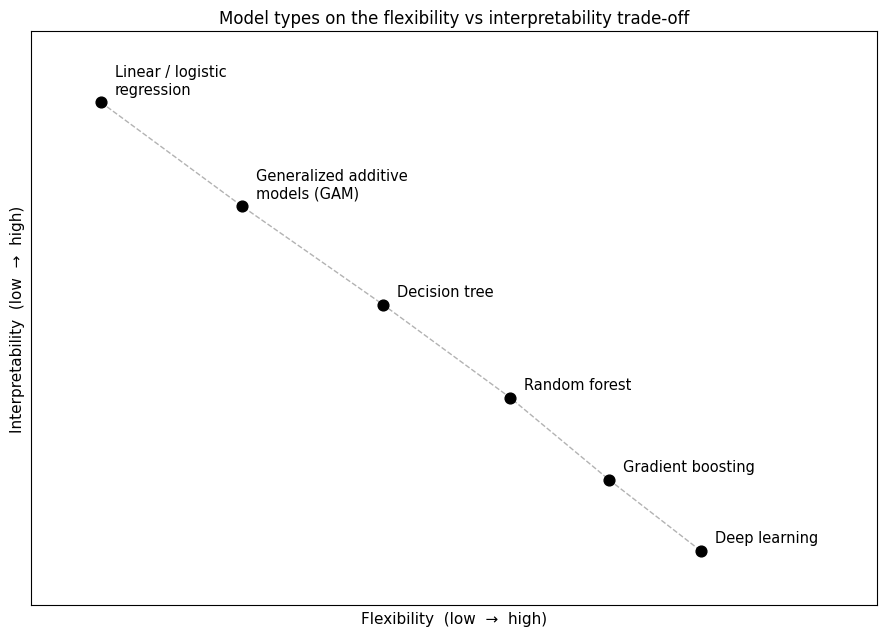

Reading the figure from top-left to bottom-right traces the complexity ladder this chapter is built around.

- **Top-left** sits linear and logistic regression: the least flexible models, and the easiest to understand. You can read the exact effect of every input straight off the model.
- **Bottom-right** sits deep learning: the most flexible, able to fit almost any pattern, and the hardest to understand. You can see what it predicts, but not really why.
- **Everything else** falls in between, trading understandability for flexibility one step at a time.

Two things about this figure matter before we go on.

First, the positions are illustrative. They show the general trade-off, not measured coordinates. Nobody has ranked these models on an exact flexibility scale, and the point is the direction, not the precise spot.

Second, and this is the part most people get backwards: moving down and to the right is not "better." It is a trade. Each step buys the ability to fit more complicated patterns, and pays for it with two costs. You lose the ability to understand the model, and you take on more risk of fitting noise. The next section shows that second cost happening, measured, on data where we know the right answer.

## 3. Watching the cost: bias, variance, and the U-curve

The last figure said that more flexibility costs you something. Now we watch that cost happen, using data where we know the right answer.

First, a change to our data. In Section 1 the true pattern was a straight line. Here we need a pattern with an actual curve in it, so we switch the true function to a wavy shape and add noise on top, the same way as before. Why the change? Because we want to show a model getting things wrong in two different ways, and a straight line is too easy. It gives a model nothing to trip over.

Here is the idea we are testing. A model can fail for two opposite reasons:

- It can be **too simple** to capture the real pattern. It misses the curve. We call this underfitting.
- It can be **too complex**, following every little wiggle in the training data, including the random noise. It memorizes the training data instead of learning the pattern. We call this overfitting.

Somewhere between too simple and too complex is a model that fits just right.

To show all three, we use a decision tree, which is a model that splits the data into groups. A tree has a setting called depth that controls how many times it is allowed to split. A shallow tree (low depth) can only make a few splits, so it stays simple. A deep tree (high depth) can keep splitting until it has carved the data into tiny pieces, so it gets very complex. Depth is our dial for turning flexibility up. (Don't worry if you aren't 100% familiar with decision trees right now. Focus on the concept I am trying to illustrate.)

So we do one thing over and over: fit a tree at depth 1, then depth 2, and so on up to depth 20. Each time, we measure the error two ways. The training error is how well the model fits the data it learned from. The test error is how well it does on data it has never seen. That second number is the one we care about, because in real trading you only ever make money on data the model has not seen before.

As you read the figure, watch the two lines behave differently.

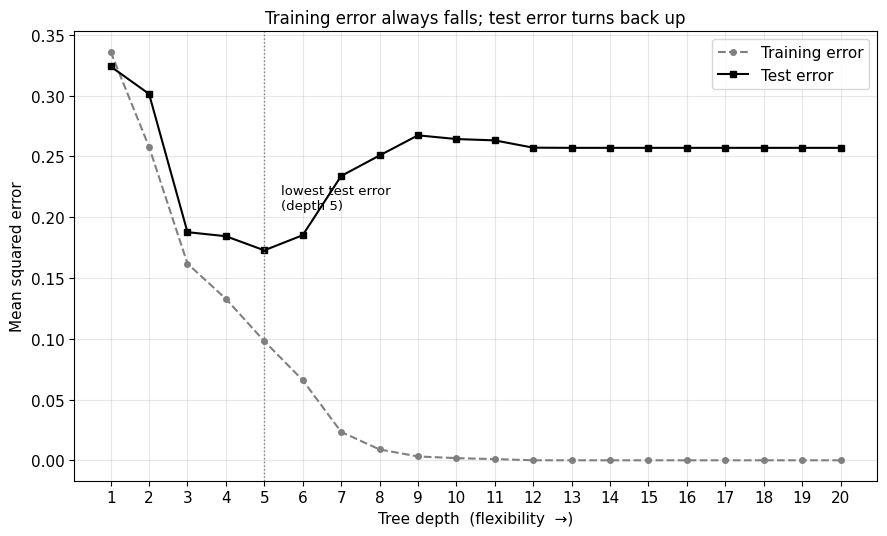

Lowest test error is at depth 5.
  Training MSE at that depth: 0.098
  Test MSE at that depth:     0.173
Training MSE at max depth 20: 0.000
Test MSE at max depth 20:     0.257


In [4]:
# =============================================================
# Sweep decision-tree depth to trace bias-variance.
# Uses the SAME six-step skeleton from Section 1, repeated at
# each depth. Only the model's depth changes.
# =============================================================

# --- Config for this section ---
# A known non-linear ("wavy") true function so that a too-simple
# model underfits and a too-complex model overfits.
DEPTHS = range(1, 21)          # tree depths to try, shallow to deep

# --- Step 1: Build features and target (known wavy truth + noise) ---
X_wave = np.random.uniform(-3, 3, size=(N_SAMPLES, 1))
true_signal = np.sin(1.5 * X_wave).ravel() + 0.5 * X_wave.ravel()
noise_wave = np.random.normal(0, NOISE_STD * 0.4, size=N_SAMPLES)
y_wave = true_signal + noise_wave

# --- Step 2: Split FIRST ---
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wave, y_wave, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

# --- Steps 3-4: Scale (fit on train, apply to both) ---
scaler_w = StandardScaler().fit(Xw_train)
Xw_train_s = scaler_w.transform(Xw_train)
Xw_test_s  = scaler_w.transform(Xw_test)

# --- Steps 5-7: Fit at each depth, record train and test MSE ---
train_mse, test_mse = [], []
for d in DEPTHS:
    tree = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_SEED)
    tree.fit(Xw_train_s, yw_train)
    train_mse.append(mean_squared_error(yw_train, tree.predict(Xw_train_s)))
    test_mse.append(mean_squared_error(yw_test,  tree.predict(Xw_test_s)))

# --- Plot the two curves ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(list(DEPTHS), train_mse, color='grey', linestyle='--',
        marker='o', markersize=4, label='Training error')
ax.plot(list(DEPTHS), test_mse, color='black', linestyle='-',
        marker='s', markersize=4, label='Test error')

# Mark the depth where test error is lowest.
best_d = list(DEPTHS)[int(np.argmin(test_mse))]
ax.axvline(best_d, color='grey', linestyle=':', linewidth=1)
ax.annotate(f'lowest test error\n(depth {best_d})',
            (best_d, min(test_mse)),
            textcoords='offset points', xytext=(12, 30), fontsize=9.5)

ax.set_xlabel('Tree depth  (flexibility  \u2192)', fontsize=11)
ax.set_ylabel('Mean squared error', fontsize=11)
ax.set_title('Training error always falls; test error turns back up', fontsize=12)
ax.set_xticks(list(DEPTHS))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Lowest test error is at depth {best_d}.")
print(f"  Training MSE at that depth: {train_mse[best_d-1]:.3f}")
print(f"  Test MSE at that depth:     {test_mse[best_d-1]:.3f}")
print(f"Training MSE at max depth {max(DEPTHS)}: {train_mse[-1]:.3f}")
print(f"Test MSE at max depth {max(DEPTHS)}:     {test_mse[-1]:.3f}")

The two lines tell the whole story.

The **training error** (the dashed line) falls the entire way down, and by depth 20 it hits **0.000**. The tree has fit the training data perfectly. Every point memorized. If training error were what mattered, we would pick the deepest tree every time and declare victory.

The **test error** (the solid line) does something completely different. It drops at first, reaches its lowest point at **depth 5**, and then climbs back up and stays there. This is the U-shape, and it is the most important picture in the chapter.

Look at what happens on each side of that low point:

- **Left of depth 5 (too simple):** the tree is too shallow to capture the wavy pattern, so it does poorly on both training and test data. This is underfitting.
- **At depth 5 (just right):** test error is at its lowest, **0.173**. The tree has captured the real pattern and stopped there.
- **Right of depth 5 (too complex):** training error keeps falling toward zero, but test error gets *worse*, ending at **0.257**. The tree is now fitting the noise in the training data, patterns that were random and will never repeat. This is overfitting.

That gap at the deep end is the key. At depth 20 the model looks flawless on training data (0.000) and is actually worse on test data (0.257) than the much simpler depth-5 tree. A model that looks perfect on the data it learned from, and fails on new data, is the single most common way trading strategies fool their builders.

Now we can name the two forces behind the U. **Bias** is error from being too simple, missing the real pattern, the left side of the curve. **Variance** is error from being too sensitive to the training data, chasing noise, the right side. Every model trades one against the other, and the bottom of the U is where the trade is best. This is the bias-variance trade-off, and it is why "more powerful" is not the same as "better." The depth-5 tree beats the depth-20 tree, even though the deeper tree is far more capable.

## 4. Watching interpretability decay

We have seen the first cost of climbing the ladder: more flexible models can overfit. Now the second cost, the one that is harder to measure but just as real. As models get more flexible, they get harder to understand.

"Understand" has a specific meaning here. It is whether you can answer the question: why did the model make this prediction? For a portfolio manager this is not a luxury. When a strategy starts losing money, you have to know why it is doing what it is doing, and when an allocator asks how the model works, "I don't know" is not an answer you can give.

We will fit three models to the same data from the last section, climbing three rungs of the ladder, and at each one we ask what the model can tell us about how it decided:

- **Linear regression**, the bottom rung.
- **A single decision tree**, one step up.
- **A random forest**, another step up.

Watch how the answer to "why did it predict that?" gets vaguer at each step.

RUNG 1 — Linear regression
  The model is one equation:  y = 0.040 + 0.815 * x
  We can read the exact effect of the input: for every 1-unit rise
  in the (scaled) feature, the prediction changes by 0.815.
  Nothing is hidden. This is total interpretability.

RUNG 2 — Decision tree (depth 3)
  The model is a set of yes/no splits. We can still draw the whole
  thing and follow any prediction down the branches (see figure).
  Readable, but already more work than one equation.



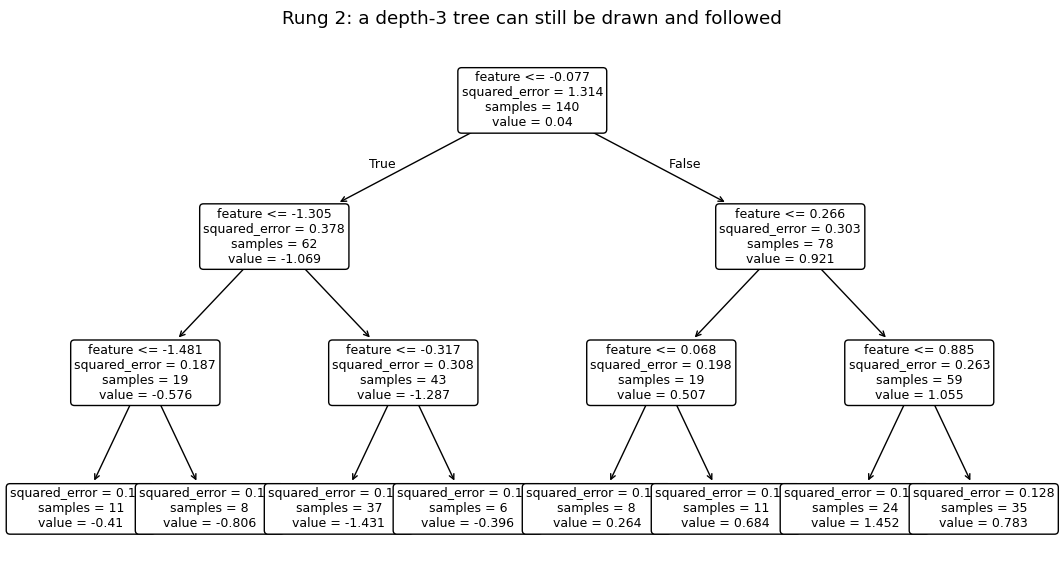

RUNG 3 — Random forest (200 trees)
  The model is 200 different trees, averaged together. There is no
  single diagram to draw. The best we can do is ask which features
  mattered most overall:
    feature: importance = 1.000
  We can see THAT the feature mattered. We can no longer see exactly
  HOW the model uses it to reach any single prediction.


In [5]:
# =============================================================
# Fit three models to the SAME wavy data from Section 3 and look
# at what each one can tell us about HOW it made its predictions.
# We reuse Xw_train_s / yw_train from Section 3.
# =============================================================
from sklearn.tree import plot_tree

# --- Rung 1: Linear regression -> read the coefficient directly ---
lin = LinearRegression().fit(Xw_train_s, yw_train)
print("RUNG 1 — Linear regression")
print(f"  The model is one equation:  y = {lin.intercept_:.3f} + {lin.coef_[0]:.3f} * x")
print(f"  We can read the exact effect of the input: for every 1-unit rise")
print(f"  in the (scaled) feature, the prediction changes by {lin.coef_[0]:.3f}.")
print(f"  Nothing is hidden. This is total interpretability.\n")

# --- Rung 2: A shallow decision tree -> read the diagram ---
tree_vis = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_SEED)
tree_vis.fit(Xw_train_s, yw_train)
print("RUNG 2 — Decision tree (depth 3)")
print("  The model is a set of yes/no splits. We can still draw the whole")
print("  thing and follow any prediction down the branches (see figure).")
print("  Readable, but already more work than one equation.\n")

fig, ax = plt.subplots(figsize=(11, 6))
plot_tree(tree_vis, filled=False, rounded=True, fontsize=9,
          feature_names=['feature'], ax=ax)
ax.set_title('Rung 2: a depth-3 tree can still be drawn and followed')
plt.tight_layout()
plt.show()

# --- Rung 3: A random forest -> no single diagram, only importances ---
forest = RandomForestRegressor(n_estimators=200, max_depth=8,
                               random_state=RANDOM_SEED)
forest.fit(Xw_train_s, yw_train)
print("RUNG 3 — Random forest (200 trees)")
print("  The model is 200 different trees, averaged together. There is no")
print("  single diagram to draw. The best we can do is ask which features")
print("  mattered most overall:")
for name, imp in zip(['feature'], forest.feature_importances_):
    print(f"    {name}: importance = {imp:.3f}")
print("  We can see THAT the feature mattered. We can no longer see exactly")
print("  HOW the model uses it to reach any single prediction.")

Line the three rungs up and the decay is obvious.

**Rung 1, linear regression,** gave us one equation: `y = 0.040 + 0.815 * x`. That single line is the entire model. We can read the exact effect of the input straight off it, and there is nothing else going on underneath. If someone asks why the model predicted what it did, we point at the equation. This is as understandable as a model gets.

**Rung 2, the decision tree,** gave us a diagram. We can still follow it: start at the top, answer each yes/no question about the feature, and walk down the branches to a prediction. Every prediction can be traced. But notice it already takes more effort than reading one equation, and this is only a depth-3 tree. At depth 15 the diagram would have thousands of boxes and no one would trace anything.

**Rung 3, the random forest,** gave us almost nothing. It is 200 separate trees averaged together, so there is no single diagram to draw. The best it could offer was an importance score, and here that score is **1.000**, which tells us only that our one feature mattered. Of course it mattered. It is the only feature there is. We can see *that* the feature was used. We can no longer see *how* the model turns it into any particular prediction.

That is the decay. Equation, then diagram, then a vague ranking. And this is the *good* case, with a single feature and only 200 trees. Climb higher, to gradient boosting or deep learning, and even the importance ranking gets shakier. You are left knowing the model works without being able to say why.

Put the two costs together now. Section 3 showed that flexible models can overfit. This section showed that flexible models are harder to understand. Both costs rise as you climb the ladder, and both are the reason the answer to "should I use a more powerful model?" is so often no. You reach for the next rung only when the problem in front of you truly needs it, and the next section shows one of the clearest cases where reaching too far actively backfires.

## 5. More features is not more signal

There is a temptation, once you have a model that can find complicated patterns, to give it everything. Every indicator, every ratio, every data series you can get your hands on, and let the model sort out what matters. This section shows why that instinct backfires.

We build a target that truly depends on just two features. Then we start adding extra features that are pure noise, random numbers with no connection to the target at all. We add them one at a time, from zero up to ten, and at each step we fit two models and check their test error:

- A **linear regression**, our simple baseline.
- A **random forest**, a flexible model of the kind people reach for when they want to "let the data speak."

The two real features never change. The only thing changing is how many useless features we pile on top. If more features were harmless, both models would hold steady. Watch whether they do.

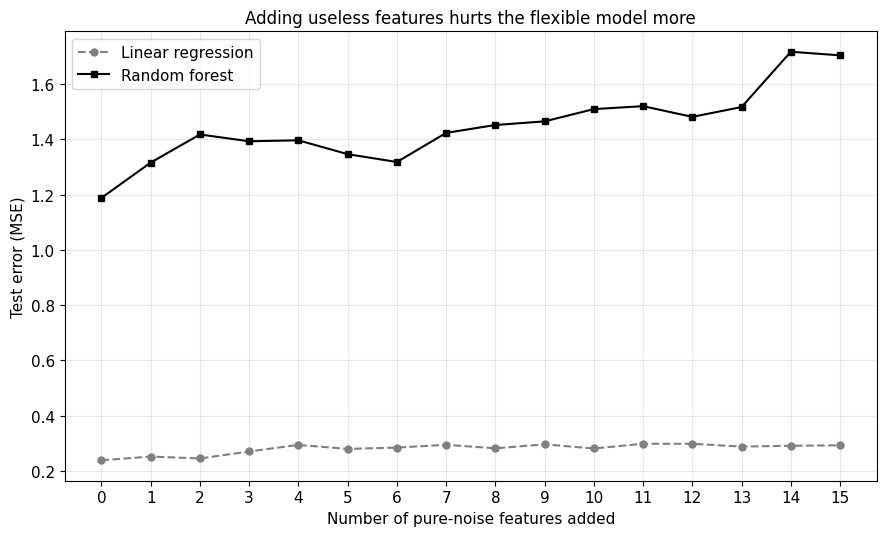

Junk feats | Linear MSE | Forest MSE
------------------------------------
         0 |      0.239 |      1.188
         1 |      0.252 |      1.316
         2 |      0.245 |      1.417
         3 |      0.271 |      1.393
         4 |      0.294 |      1.396
         5 |      0.280 |      1.346
         6 |      0.285 |      1.318
         7 |      0.295 |      1.423
         8 |      0.282 |      1.452
         9 |      0.296 |      1.465
        10 |      0.281 |      1.509
        11 |      0.299 |      1.520
        12 |      0.298 |      1.481
        13 |      0.288 |      1.516
        14 |      0.291 |      1.716
        15 |      0.293 |      1.703


In [7]:
# =============================================================
# Start with 2 real features, then add up to 15 pure-noise
# features. At each step, fit a linear model and a random forest
# and record test error. Same six-step skeleton throughout.
#
# NOTE: the target is LINEAR in the two real features (no
# interaction). This is deliberate. We want a case where the
# simple model is entirely capable, so any damage from junk
# features shows up cleanly against a fair baseline.
# =============================================================

# --- Config for this section ---
N_INFORMATIVE = 2        # features that truly drive the target
MAX_NOISE     = 15       # how many junk features we add, one at a time
N_SMALL       = 80       # smaller sample: junk features bite hardest on little data

# --- Build the target from 2 real features (+ noise), strictly linear ---
X_real = np.random.uniform(-2, 2, size=(N_SMALL, N_INFORMATIVE))
y_feat = (2.0 * X_real[:, 0]
          - 1.5 * X_real[:, 1]
          + np.random.normal(0, NOISE_STD * 0.5, size=N_SMALL))

# --- Pre-generate a pool of pure-noise features (no link to target) ---
noise_pool = np.random.normal(0, 1, size=(N_SMALL, MAX_NOISE))

lin_scores, rf_scores, n_junk = [], [], []

for k in range(0, MAX_NOISE + 1):
    if k == 0:
        X_k = X_real
    else:
        X_k = np.hstack([X_real, noise_pool[:, :k]])

    # Step 2: split first
    Xk_tr, Xk_te, yk_tr, yk_te = train_test_split(
        X_k, y_feat, test_size=TEST_SIZE, random_state=RANDOM_SEED)

    # Steps 3-4: scale (fit on train, apply to both)
    sc = StandardScaler().fit(Xk_tr)
    Xk_tr_s, Xk_te_s = sc.transform(Xk_tr), sc.transform(Xk_te)

    # Steps 5-7: fit both models, record test MSE
    lin_k = LinearRegression().fit(Xk_tr_s, yk_tr)
    rf_k = RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED
                                 ).fit(Xk_tr_s, yk_tr)
    lin_scores.append(mean_squared_error(yk_te, lin_k.predict(Xk_te_s)))
    rf_scores.append(mean_squared_error(yk_te, rf_k.predict(Xk_te_s)))
    n_junk.append(k)

# --- Plot test error vs number of junk features ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(n_junk, lin_scores, color='grey', linestyle='--',
        marker='o', markersize=5, label='Linear regression')
ax.plot(n_junk, rf_scores, color='black', linestyle='-',
        marker='s', markersize=5, label='Random forest')
ax.set_xlabel('Number of pure-noise features added', fontsize=11)
ax.set_ylabel('Test error (MSE)', fontsize=11)
ax.set_title('Adding useless features hurts the flexible model more', fontsize=12)
ax.set_xticks(n_junk)
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Junk feats':>10} | {'Linear MSE':>10} | {'Forest MSE':>10}")
print("-" * 36)
for k, lm, rm in zip(n_junk, lin_scores, rf_scores):
    print(f"{k:>10} | {lm:>10.3f} | {rm:>10.3f}")

This is the clearest picture in the notebook, so read it carefully.

The **linear regression** (dashed line) barely moves. It starts at a test error of **0.239** with just the two real features. After we bury it under fifteen useless features, it sits at **0.293**. Almost no change. When a useless feature shows up, the linear model gives it almost no weight and moves on. The junk costs it next to nothing.

The **random forest** (solid line) does the opposite. It climbs from **1.188** up to **1.703** as the junk piles up, ending more than five times worse than the linear model. Each useless feature gives the forest one more thing to split on, and with only 80 rows of data it keeps treating random patterns as if they were real. The more junk we give it, the more fake structure it finds.

Now look at the very first point on the chart, before we add any junk at all. Even there, with only the two real features, the forest (1.188) is already far worse than the linear model (0.239). The true pattern in this data is a straight line, so the simple model was the right tool from the start and the forest was the wrong one. Adding useless features did not create the problem. It made a problem that was already there even worse.

So the lesson is this: more features are not the same as more signal. A model that hunts for complicated patterns will find them whether they are real or not. On a simple problem with limited data, that is a weakness, not a strength. The linear model won because it was simpler. It had no spare capacity to waste on noise.

And it gets worse the more powerful the model is. We showed this with a random forest, but the same thing happens as you move to heavier models. The more flexible the model, the more room it has to chase noise, so the harder these useless features hit. Hand the same junk to a gradient boosting model or a neural network and it would usually struggle just as much or more. The linear model came through fine because it had the least room to go wrong.

This is what "do not bring a tank to a knife fight" means in practice. The tank does not just fail to help. It gets in its own way.

## 6. What these figures showed

We used made-up data for this whole notebook, and now you can see why. Every lesson here depended on knowing the true answer, so we could catch a model getting it wrong. With market data, none of these mistakes would have announced themselves.

Four pictures, four lessons:

- **The map** placed the models on a single trade-off: as flexibility goes up, understandability goes down.
- **The U-curve** showed the first cost of climbing. Past a point, more flexibility means worse performance on new data, not better. That is overfitting, and training error will not warn you about it.
- **The interpretability rungs** showed the second cost. An equation became a diagram became a vague ranking, until we could no longer say why the model did what it did.
- **The noise-feature test** showed that more features are not more signal, and that a flexible model on a simple problem can lose to a straight line before you even start.

None of this says machine learning is useless. It says machine learning is a specific tool for a specific situation: enough data, real complexity in the relationship, and a willingness to give up understanding the model in exchange. When those conditions are not met, the simpler methods from earlier in this book are not a compromise. They are the better choice.

In the next chapter we stop working with made-up data and put this to the test on a real strategy. We will walk the full machine learning process end to end, and we will let one of these problems show up live, so you can see what it looks like when it is not a demonstration but your own strategy on the line.